In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

Function 1: Searching for Contamination Sources

This may sound simple because you only have a two-dimensional input, however it is a very difficult problem. It corresponds to trying to find the source of radiation in some square area. However, you can only detect the radiation once you are very close to it, meaning most of the readings will be zero. There are two sources, one is not too dangerous, so make sure you try to find both modes of the function.

Goal: Find the locations of two contamination (radiation) sources in a 2D area (think of a square field).

Challenge

Sparse Signal: We only detect radiation when you are very close to a source; otherwise, our readings are (almost) zero.

Multiple Sources: There are two sources, and one is less dangerous (lower intensity), so you must find both.

Strategy

Exploration vs. Exploitation: We first explore the area to find both sources, not just focus on the first one we find. Then we exploit around the inputs for which the observations are significantly greater than zero.

In [2]:
def queries_for_function(number):
    if number < 1 or number > 8:
        return []
        
    with open('../queries.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        file_content = file.read()
        
    all_queries = file_content.split('])]')
    
    formatted_queries = [query.replace('\n', '') + '])]' for query in all_queries if query]
    
    actual_queries = []
    for query in formatted_queries:
        formatted_query = query.replace('array(', '').replace(')', '').strip()
        
        try:
            query_formatted_as_list = eval(formatted_query)  # Ensure eval is safe or replace with a safer alternative
            query_as_2d_array = np.array(query_formatted_as_list, dtype=object)
            actual_queries.append(query_as_2d_array[number - 1])
        except (SyntaxError, IndexError, ValueError) as e:
            print(f"Warning: Skipping query due to error - {e}")
            continue

    return actual_queries


def observations_for_function(number):
    if number < 1 or number > 8:
        return []
    
    data = []
    
    with open('../observations.txt', 'r') as file:  # Fixed the path separator for cross-platform compatibility
        for line in file:
            try:
                # Extract the float values from the line
                values = [float(value.split('(')[1].split(')')[0]) for value in line.strip().split(', ')]
                data.append(values)
            except (IndexError, ValueError) as e:
                print(f"Warning: Skipping line due to error - {e}")
                continue
            
    # Convert the list of lists into a numpy array
    data_array = np.array(data)
    
    # Extract each column as a numpy array
    columns = [data_array[:, i] for i in range(data_array.shape[1])] if data_array.size > 0 else []
    
    return columns[number - 1] if number - 1 < len(columns) else []

In [3]:
X = np.load("initial_inputs.npy")
X, len(X)

(array([[0.31940389, 0.76295937],
        [0.57432921, 0.8798981 ],
        [0.73102363, 0.73299988],
        [0.84035342, 0.26473161],
        [0.65011406, 0.68152635],
        [0.41043714, 0.1475543 ],
        [0.31269116, 0.07872278],
        [0.68341817, 0.86105746],
        [0.08250725, 0.40348751],
        [0.88388983, 0.58225397]]),
 10)

In [4]:
#new_query_1 =  np.array([1.00000e-06, 9.99999e-01])
#new_query_2 =  np.array([0.999999, 0.999999])
#new_query_3 =  np.array([1.e-06, 1.e-06])
#new_query_4 =  np.array([9.99999e-01, 1.00000e-06])
#new_query_5 =  np.array([6.76767e-01, 1.00000e-06])
#X = np.vstack([X, new_query_1, new_query_2, new_query_3, new_query_4, new_query_5])
#X

queries = queries_for_function(1)
X = np.vstack([X, queries])
X, len(X)

(array([[3.19403889e-01, 7.62959374e-01],
        [5.74329215e-01, 8.79898105e-01],
        [7.31023631e-01, 7.32999876e-01],
        [8.40353417e-01, 2.64731614e-01],
        [6.50114060e-01, 6.81526352e-01],
        [4.10437137e-01, 1.47554299e-01],
        [3.12691157e-01, 7.87227779e-02],
        [6.83418169e-01, 8.61057464e-01],
        [8.25072518e-02, 4.03487506e-01],
        [8.83889829e-01, 5.82253974e-01],
        [9.99999000e-01, 9.99999000e-01],
        [1.00000000e-06, 1.00000000e-06],
        [9.99999000e-01, 1.00000000e-06],
        [6.76767000e-01, 1.00000000e-06],
        [4.04041000e-01, 4.64647000e-01],
        [9.16938000e-01, 5.46605000e-01],
        [3.37320000e-01, 8.03721000e-01],
        [8.21408000e-01, 4.89430000e-01],
        [6.28667000e-01, 6.94250000e-02],
        [1.91025000e-01, 7.10641000e-01],
        [1.00000000e-06, 9.99999000e-01]]),
 21)

In [5]:
y = np.load("initial_outputs.npy")
y, len(y)

(array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
         3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
        -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
         6.22985647e-048]),
 10)

In [6]:
#y = np.append(y, [0.0, 1.517648729565899e-192, 2.31546114628124e-248, 0.0, 5.4713831123687026e-170], axis=0)
#y

observations = observations_for_function(1)
for observation in observations:
    y = np.append(y, [observation], axis=0)
y, len(y)

(array([ 1.32267704e-079,  1.03307824e-046,  7.71087511e-016,
         3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
        -2.08909327e-091,  2.53500115e-040,  3.60677119e-081,
         6.22985647e-048,  1.51764873e-192,  2.31546115e-248,
         0.00000000e+000,  5.47138311e-170, -3.72500843e-003,
        -3.53657121e-063,  5.05208032e-081,  1.05988447e-040,
        -2.63964724e-118, -5.21092353e-096,  0.00000000e+000]),
 21)

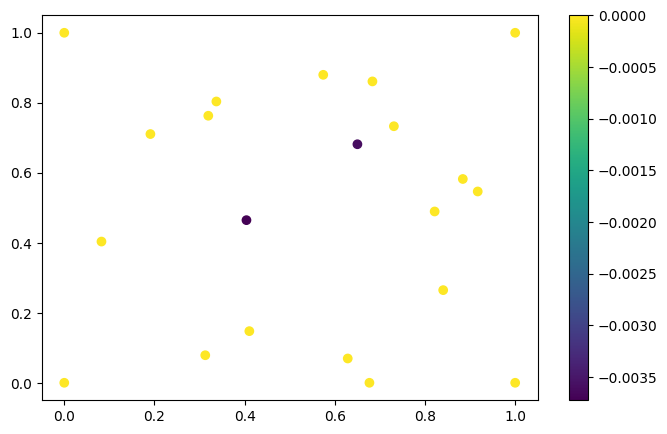

In [7]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(8)
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.colorbar()

Text(0.5, 0.92, 'Scatter Plot of Contamination Sources Input Data Points with Output Variable y')

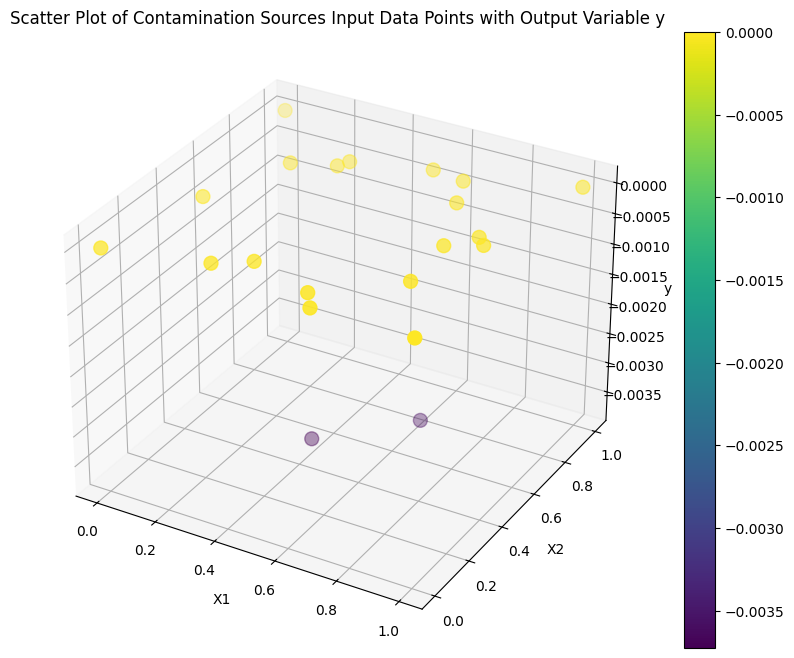

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X[:,0], X[:,1], y, c=y, cmap='viridis', s=100)

plt.colorbar(sc)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')

ax.set_title('Scatter Plot of Contamination Sources Input Data Points with Output Variable y')


In [9]:
#UCB is useful when you want a balance between exploring new areas of the search space (high uncertainty) and exploiting known areas 
#with high mean values. The parameter β controls this balance. It's a good general-purpose acquisition function for many optimization problems.
def upper_confidence_bound(post_mean, post_std, beta):
    ucb = post_mean + beta * post_std # upper confidence bpon (ucb) = mu + kappa * sigma 
    print("\n\nUCB Shape: ", np.shape(ucb))
    return ucb


#PI is more focused on exploitation, as it prioritizes areas where the predicted mean is higher than the current best observed value (ymax)
#Use PI when you have a well-calibrated model and you want to focus on improving the best observed value.
def probability_of_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI Shape: ", np.shape(PI))
    return PI


def probability_of_improvement_with_exploration_term(post_mean, post_std, y_max, epsilon):
    # Calculate the improvement with exploration term
    improvement = post_mean - (y_max + epsilon)
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the probability of improvement using the cumulative distribution function (CDF) of the normal distribution
    PI = norm.cdf(Z)
    print("\n\nPI With Exploitation Term Shape: ", np.shape(PI))
    return PI


#EI provides a balance between exploration and exploitation, similar to UCB, but it also considers the magnitude of improvement.
#Use EI when you want to maximize the expected improvement over the current best observed value.
def expected_improvement(post_mean, post_std, y_max):
    # Calculate the improvement
    improvement = post_mean - y_max
    
    # Calculate the Z value
    Z = improvement / post_std
    
    # Calculate the expected improvement
    EI = improvement * norm.cdf(Z) + post_std * norm.pdf(Z)
    print("\n\nEI Shape: ", np.shape(EI))
    return EI

#Thompson Sampling is useful when you want to sample from the posterior distribution of the model, which inherently balances exploration and exploitation.
#Use Thompson Sampling when you want a stochastic approach to selecting the next point.
def thompson_sampling(post_mean, post_std):
    # Sample from the posterior distribution
    samples = np.random.normal(post_mean, post_std)
    print("\n\nThompson Samples Shape: ", np.shape(samples))
    return samples

In [10]:
def query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, acquisition_func):
    
    beta = 1.96
    model = GaussianProcessRegressor()
    model.fit(X, y)

    
    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T
    
    post_mean, post_std = model.predict(x_grid, return_std=True) #post_mean is y_pred and post_std is sigma i.e. s
    #acquisition_function = post_mean + beta * post_std # upper confidence bound (ucb) = mu + kappa * sigma mu + kappa * sigma 
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
        
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)  # Define y_max as the maximum observed value
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
        
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)

    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)

    else: #thompson_sampling
         acquisition_function = acquisition_func(post_mean, post_std)
    
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]
    
    x = x.reshape(1,2)
    y_pred = np.array([y_pred])
    
    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}") 
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))
   
    return x, y_pred

In [11]:
def next_query_with_default_kernel(X, y, x1_grid, x2_grid):
    x_random = np.random.uniform(size = 2)
    print(f"Random Query: {x_random[0]:.6f}-{x_random[1]:.6f}")

    x_ucb, y_pred_ucb = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, upper_confidence_bound)
    
    x_pi, y_pred_pi = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, probability_of_improvement)
    
    x_piet, y_pred_piet = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, probability_of_improvement_with_exploration_term)
    
    x_ei, y_pred_ei = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, expected_improvement)
    
    x_ts, y_pred_ts = query_black_box_function_with_default_kernel(X, y, x1_grid, x2_grid, thompson_sampling)

    return x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts

Exploration: Explore the whole space with defalut RBF Kernel

In [12]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y,x1_grid, x2_grid)

Random Query: 0.023408-0.277948


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.242425-0.999999)
Predicted Value at (0.242425-0.999999) is 0.010674325217489677
Index of maximum acquisition function value:  9924


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.373738-0.000001)
Predicted Value at (0.373738-0.000001) is 0.008431699021832228
Index of maximum acquisition function value:  37


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -4.875685561782183e-07
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.222223)
Predicted Value at (0.999999-0.222223) is 0.011347512355654732
Index of maximum acquisition function value:  2299


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.202021-0.999999)
Predicted Value at (0.20202

Exploitation: Exploit around [6.50114060e-01, 6.81526352e-01]

In [13]:
x1_grid = np.linspace(0.62, 0.68, 100) 
x2_grid = np.linspace(0.65, 0.70, 100)
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y,x1_grid, x2_grid)

Random Query: 0.603822-0.782234


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.680000-0.700000)
Predicted Value at (0.680000-0.700000) is -0.0021875777798341395
Index of maximum acquisition function value:  9999


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.620000-0.650000)
Predicted Value at (0.620000-0.650000) is -0.005195244591489467
Index of maximum acquisition function value:  0


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.620000-0.650000)
Predicted Value at (0.620000-0.650000) is -0.005195244591489467
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.620000-0.650000)
Predicted Value at (0.620000-0.650000) is -0.005195244591489467
Index of maximum acquisition function value:  0


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.680000-0.700000)
Predicted Value at (0.680000

In [14]:
x1_grid = np.linspace(0.37, 0.43, 100)
x2_grid = np.linspace(0.43, 0.48, 100)
x_ucb, y_pred_ucb, x_pi, y_pred_pi, x_piet, y_pred_piet, x_ei, y_pred_ei, x_ts, y_pred_ts = next_query_with_default_kernel(X, y, x1_grid, x2_grid)

Random Query: 0.164985-0.249728


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.480000)
Predicted Value at (0.370000-0.480000) is -0.0016776145077030402
Index of maximum acquisition function value:  9900


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0017556735008629084
Index of maximum acquisition function value:  0


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0017556735008629084
Index of maximum acquisition function value:  0


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0017556735008629084
Index of maximum acquisition function value:  0


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370606-0.464848)
Predicted Value at (0.370

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters with gp_minimize

In [15]:
from sklearn.gaussian_process.kernels import Matern, RationalQuadratic, DotProduct

def query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, acquisition_func, kernel_type, rbf_lengthscale, noise_assumption, restarts, beta):
    # Define the kernel based on the kernel_type parameter
    if kernel_type == 'RBF':
        kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2)) * C(1.0, (1e-3, 1e3))

    elif kernel_type == 'Matern':
        kernel = Matern(length_scale=rbf_lengthscale, length_scale_bounds=(1e-2, 1e2), nu=1.5)

    elif kernel_type == 'RationalQuadratic':
        kernel = RationalQuadratic(length_scale=rbf_lengthscale, alpha=1.0) * C(1.0, (1e-3, 1e3))
      
    elif kernel_type == 'DotProduct':
        kernel = DotProduct(sigma_0=1.0, sigma_0_bounds=(1e-3, 1e3)) + C(1.0, (1e-3, 1e3))
    else:
        kernel = None

    # Create and fit the Gaussian Process model
    if kernel is None:
        model = GaussianProcessRegressor()
    else:   
        model = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption, n_restarts_optimizer=restarts)

    model.fit(X, y)

    # Create the grid for predictions
    x1_grid, x2_grid = np.meshgrid(x1_grid, x2_grid)
    x_grid = np.vstack([x1_grid.ravel(), x2_grid.ravel()]).T

    # Predict the mean and standard deviation
    post_mean, post_std = model.predict(x_grid, return_std=True)

    # Compute the acquisition function
    if acquisition_func == upper_confidence_bound:
        acquisition_function = acquisition_func(post_mean, post_std, beta)
    elif acquisition_func == probability_of_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    elif acquisition_func == probability_of_improvement_with_exploration_term:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max, 0.8)
    elif acquisition_func == expected_improvement:
        y_max = np.max(y)
        acquisition_function = acquisition_func(post_mean, post_std, y_max)
    else:  # thompson_sampling
        acquisition_function = acquisition_func(post_mean, post_std)

    # Find the point that maximizes the acquisition function
    x = x_grid[np.argmax(acquisition_function)]
    y_pred = post_mean[np.argmax(acquisition_function)]

    x = x.reshape(1, 2)
    y_pred = np.array([y_pred])

    print(f"Query to Black Box Function Maximizes at Input: ({x[0][0]:.6f}-{x[0][1]:.6f})")
    print(f"Predicted Value at ({x[0][0]:.6f}-{x[0][1]:.6f}) is {y_pred[0]}")
    print("Index of maximum acquisition function value: ", np.argmax(acquisition_function))

    return x, y_pred

In [16]:
# Install scikit-optimize if not already installed
%pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args

x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)

# Define the search space
search_space = [
    Real(0.01, 1.0, name='lengthscale'),
    Real(1e-10, 1e-1, name='noise_assumption'),
    Integer(0, 15, name='restarts'),
    Real(1.0, 3.0, name='beta'),
    Categorical([upper_confidence_bound, probability_of_improvement, 
                 probability_of_improvement_with_exploration_term, 
                 expected_improvement, thompson_sampling], name='acquisition_func'),
    Categorical(['None', 'RBF', 'Matern', 'RationalQuadratic', 'DotProduct'], name='kernel_type')
]

# Define the objective function
@use_named_args(search_space)
def objective_function_gp(lengthscale, noise_assumption, restarts, beta, acquisition_func, kernel_type):
    global best_x_ucb, best_y_pred_ucb, best_params

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, x1_grid, x2_grid, 
        acquisition_func=acquisition_func,
        kernel_type=kernel_type,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=restarts,
        beta=beta
    )
    
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Perform Bayesian optimization
result = gp_minimize(
    func=objective_function_gp,
    dimensions=search_space,
    n_calls=100,  # Number of evaluations
    random_state=42
)

# Extract the best parameters
(best_rbf_lengthscale, best_noise_assumption, best_restarts, 
 best_beta, best_acquisition_func, best_kernel_type) = result.x
print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, acquisition_func={best_acquisition_func.__name__}, "
      f"kernel_type={best_kernel_type}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, x1_grid, x2_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale, 
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -4.875685561782183e-07
Index of maximum acquisition function value:  0


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is -0.00013483455876956197
Index of maximum acquisition function value:  9900


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.222223)
Predicted Value at (0.999999-0.222223) is 0.011347512355654732
Index of maximum acquisition function value:  2299


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.414142-0.303031)
Predicted Value at (0.414142-0.303031) is -9.977305236017675e-05
Index of maximum acquisition function value:  3041


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is -0.0004179493083083522
Index of maximum acquisition function value:  9900


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is -0.00011099116453573918
Index of maximum acquisition function value:  9900


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Predicted Value at (0.000001-0.999999) is -0.0004271830177051626
Index of maximum acquisition function value:  9900


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.999999)
Pr

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


...

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(




Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.686868-0.878787)
Predicted Value at (0.686868-0.878787) is -0.000349072372379919
Index of maximum acquisition function value:  8768


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(




PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.000001-0.000001)
Predicted Value at (0.000001-0.000001) is -6.700849190571751e-05
Index of maximum acquisition function value:  0
Best Parameters: rbf_lengthscale=0.9391671819255929, noise_assumption=7.787668402355627e-05, restarts=15, beta=2.2349630192554333, acquisition_func=expected_improvement, kernel_type=None


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.222223)
Predicted Value at (0.999999-0.222223) is 0.011347512355654732
Index of maximum acquisition function value:  2299


(array([[0.999999  , 0.22222278]]), array([0.01134751]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with gp_minimize

In [17]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.999999-0.222223)
Predicted Value at (0.999999-0.222223) is 0.011347512355654732
Index of maximum acquisition function value:  2299


(array([[0.999999  , 0.22222278]]), array([0.01134751]))

Exploitation: Expoit for Radiation Source 1 around [6.50114060e-01, 6.81526352e-01]

In [18]:
x1_grid = np.linspace(0.62, 0.68, 100) 
x2_grid = np.linspace(0.65, 0.70, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.620000-0.650000)
Predicted Value at (0.620000-0.650000) is -0.005195244591489467
Index of maximum acquisition function value:  0


(array([[0.62, 0.65]]), array([-0.00519524]))

Exploitation: Expoit for Radiation Source 2 around [4.04041000e-01, 4.64647000e-01]

In [19]:
x1_grid = np.linspace(0.37, 0.43, 100)
x2_grid = np.linspace(0.43, 0.48, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0017556735008629084
Index of maximum acquisition function value:  0


(array([[0.37, 0.43]]), array([-0.00175567]))

Hyperparameter Tuning: Find best hyperparameters Best Kernel and Hyperparameters using from bayes_opt import BayesianOptimization

In [20]:
%pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def objective_function_bo(lengthscale, noise_assumption, restarts, beta, kernel_type, acquisition_func):
    # Map integer values to kernel types and acquisition functions
    kernel_types = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct']
    acquisition_funcs = [
        upper_confidence_bound,
        probability_of_improvement,
        probability_of_improvement_with_exploration_term,
        expected_improvement,
        thompson_sampling
    ]
    kernel_type_str = kernel_types[int(round(kernel_type))]
    acquisition_func_obj = acquisition_funcs[int(round(acquisition_func))]

    x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
        X, y, x1_grid, x2_grid,
        acquisition_func=acquisition_func_obj,
        kernel_type=kernel_type_str,
        rbf_lengthscale=lengthscale,
        noise_assumption=noise_assumption,
        restarts=int(round(restarts)),
        beta=beta
    )
    # Return the negative of the prediction as we want to maximize y_pred_ucb
    return -y_pred_ucb[0]

# Define the bounds for each parameter
pbounds = {
    'lengthscale': (0.01, 1.0),
    'noise_assumption': (1e-10, 1e-1),
    'restarts': (0, 15),
    'beta': (1.0, 3.0),
    'kernel_type': (0, 3),  # 0: RBF, 1: Matern, 2: RationalQuadratic, 3: DotProduct
    'acquisition_func': (0, 4)  # 0: UCB, 1: PI, 2: PI+explore, 3: EI, 4: Thompson
}

optimizer = BayesianOptimization(
    f=objective_function_bo,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(
    init_points=5,
    n_iter=100
)

# Extract the best parameters
best_params = optimizer.max['params']
best_rbf_lengthscale = best_params['lengthscale']
best_noise_assumption = best_params['noise_assumption']
best_restarts = int(round(best_params['restarts']))
best_beta = best_params['beta']
best_kernel_type = ['RBF', 'Matern', 'RationalQuadratic', 'DotProduct'][int(round(best_params['kernel_type']))]
best_acquisition_func = [
    upper_confidence_bound,
    probability_of_improvement,
    probability_of_improvement_with_exploration_term,
    expected_improvement,
    thompson_sampling
][int(round(best_params['acquisition_func']))]

print(f"Best Parameters: rbf_lengthscale={best_rbf_lengthscale}, noise_assumption={best_noise_assumption}, "
      f"restarts={best_restarts}, beta={best_beta}, kernel_type={best_kernel_type}, "
      f"acquisition_func={best_acquisition_func.__name__}")

# Use the best parameters to query the black-box function
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(
    X, y, x1_grid, x2_grid,
    acquisition_func=best_acquisition_func,
    kernel_type=best_kernel_type,
    rbf_lengthscale=best_rbf_lengthscale,
    noise_assumption=best_noise_assumption,
    restarts=best_restarts,
    beta=best_beta
)

x_ucb, y_pred_ucb


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
|   iter    |  target   | acquis... |   beta    | kernel... | length... | noise_... | restarts  |
-------------------------------------------------------------------------------------------------


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.00020029228707248308
Index of maximum acquisition function value:  0
| 1         | 0.0002003 | 1.498     | 2.901     | 2.196     | 0.6027    | 0.0156    | 2.34      |


UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0003179342595752274
Index of maximum acquisition function value:  0
| 2         | 0.0003179 | 0.2323    | 2.732     | 1.803     | 0.711     | 0.002058  | 14.55     |


EI Shape:  (10000,)
Query to Black Box Function Maximi


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\harji\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0002744860945778777
Index of maximum acquisition function value:  0
| 6         | 0.0002745 | 3.473     | 1.412     | 0.3358    | 0.2771    | 0.005709  | 7.968     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.00034766886427936095
Index of maximum acquisition function value:  0
| 7         | 0.0003477 | 1.828     | 2.721     | 0.6717    | 0.54      | 0.08617   | 0.9065    |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.00034792614820631693
Index of maximum acquisition function value:  0
| 8         | 0.0003479 | 3.083     | 1.293     | 1.023     | 0.3186    | 0.07029   | 8.078     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The opti



Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.383939-0.477980)
Predicted Value at (0.383939-0.477980) is -0.00034854527833139544
Index of maximum acquisition function value:  9523
| 11        | 0.0003485 | 3.559     | 1.205     | 1.377     | 0.09196   | 0.04179   | 7.393     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0003478677532933255
Index of maximum acquisition function value:  0
| 12        | 0.0003479 | 3.472     | 1.102     | 0.7203    | 0.06909   | 0.0739    | 7.144     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -9.371098268003017e-05
Index of maximum acquisition function value:  0
| 13        | 9.371e-05 | 2.95      | 2.583     | 1.729     | 0.3966    | 0.05723   | 1.117     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000

...



UCB Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.480000)
Predicted Value at (0.370000-0.480000) is -0.0002803538808876865
Index of maximum acquisition function value:  9900
| 98        | 0.0002804 | 0.4581    | 2.971     | 2.873     | 0.6696    | 0.01749   | 8.389     |


Thompson Samples Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.379091-0.437071)
Predicted Value at (0.379091-0.437071) is -0.0001052338191468914
Index of maximum acquisition function value:  1415
| 99        | 0.0001052 | 3.672     | 1.515     | 2.434     | 0.7942    | 0.04866   | 4.177     |


PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0003479851910155371
Index of maximum acquisition function value:  0
| 100       | 0.000348  | 0.8696    | 2.891     | 1.309     | 0.4872    | 0.06663   | 11.91     |


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarn



PI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.00020891633152326255
Index of maximum acquisition function value:  0
| 101       | 0.0002089 | 1.229     | 2.195     | 2.256     | 0.417     | 0.01409   | 0.1337    |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0003487750370369064
Index of maximum acquisition function value:  0
| 102       | 0.0003488 | 2.782     | 1.847     | 0.8109    | 0.5425    | 0.01275   | 8.645     |


EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0003484224240974448
Index of maximum acquisition function value:  0
| 103       | 0.0003484 | 2.586     | 2.295     | 0.9676    | 0.5248    | 0.03908   | 8.324     |


PI With Exploitation Term Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.

C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The 

(array([[0.37, 0.43]]), array([-0.00308631]))

Exploration: Explore the whole space with Kernel of Choice and Best Hyperparameters with BaysianOptimization

In [21]:
x1_grid = np.linspace(0.000001, 0.999999, 100)
x2_grid = np.linspace(0.000001, 0.999999, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)

x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.848484-0.797979)
Predicted Value at (0.848484-0.797979) is 0.0015619297117714435
Index of maximum acquisition function value:  7984


(array([[0.84848415, 0.7979792 ]]), array([0.00156193]))

Exploitation: Expoit for Radiation Source 1 around [6.50114060e-01, 6.81526352e-01]

In [22]:
x1_grid = np.linspace(0.62, 0.68, 100) 
x2_grid = np.linspace(0.65, 0.70, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.680000-0.650000)
Predicted Value at (0.680000-0.650000) is -0.003143240250353983
Index of maximum acquisition function value:  99


C:\Users\harji\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\gaussian_process\_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


(array([[0.68, 0.65]]), array([-0.00314324]))

Exploitation: Expoit for Radiation Source 2 around [4.04041000e-01, 4.64647000e-01]

In [23]:
x1_grid = np.linspace(0.37, 0.43, 100)
x2_grid = np.linspace(0.43, 0.48, 100)
x_ucb, y_pred_ucb = query_black_box_function_with_kernel_choice(X, y, x1_grid, x2_grid, 
                                                                acquisition_func=best_acquisition_func, 
                                                                kernel_type=best_kernel_type, rbf_lengthscale=best_rbf_lengthscale, 
                                                                noise_assumption=best_noise_assumption, restarts=best_restarts, beta=best_beta)
x_ucb, y_pred_ucb



EI Shape:  (10000,)
Query to Black Box Function Maximizes at Input: (0.370000-0.430000)
Predicted Value at (0.370000-0.430000) is -0.0030863089553609716
Index of maximum acquisition function value:  0


(array([[0.37, 0.43]]), array([-0.00308631]))